In [1]:
import importlib.util, subprocess, sys
packages = {"numpy":"numpy", "PIL":"Pillow", "matplotlib":"matplotlib", "sklearn":"scikit-learn", "threadpoolctl":"threadpoolctl"}
missing = [p for name,p in packages.items() if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable,"-m","pip","install",*missing])
print("Dependencies ready.")

Dependencies ready.


In [2]:
"""MLP du TP : NumPy, ReLU, softmax et gradients calcules a la main."""
from pathlib import Path
import os, io, json, csv, zipfile, hashlib, urllib.request, shutil, time, copy
from collections import Counter
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
from threadpoolctl import threadpool_limits

DATA_URL = ('https://www.kaggle.com/api/v1/datasets/download/benaddym/'
            'amazigh-handwritten-character-database-amhcd?datasetVersionNumber=1')

def load_data(archive='amhcd.zip'):
    archive = Path(archive)
    if not archive.exists():
        print('Downloading the public AMHCD archive...', flush=True)
        with urllib.request.urlopen(DATA_URL, timeout=120) as response, archive.open('wb') as f:
            shutil.copyfileobj(response, f)
    arrays, labels, names, seen = [], [], [], {}
    raw_hashes, sizes, modes = set(), set(), set()
    removed, conflicts = 0, []
    hashes, conflicting_hashes, counts = [], set(), Counter()
    with zipfile.ZipFile(archive) as z:
        # Une seule copie : ne pas melanger les deux dossiers de l'archive.
        paths = sorted(n for n in z.namelist()
                       if n.startswith('AMHCD_64/AMHCD_64/') and n.endswith('.jpeg'))
        if not paths:
            raise ValueError('Expected AMHCD version 1 folder is missing. Check the ZIP file.')
        classes = sorted({Path(n).parent.name for n in paths})
        assert len(classes) == 33
        for name in paths:
            raw = z.read(name)
            raw_hashes.add(hashlib.sha256(raw).hexdigest())
            label = Path(name).parent.name
            with Image.open(io.BytesIO(raw)) as image:
                sizes.add(image.size); modes.add(image.mode)
                image = image.convert('L').resize((32, 32), Image.Resampling.BILINEAR)
                pixels = np.asarray(image, dtype=np.uint8)
            # Eviter une image identique dans deux partitions apres pretraitement.
            digest = hashlib.sha256(pixels.tobytes()).hexdigest()
            counts[digest] += 1
            if digest in seen:
                if seen[digest] != label:
                    conflicts.append((name, seen[digest], label))
                    conflicting_hashes.add(digest)
                removed += 1
                continue
            seen[digest] = label
            hashes.append(digest)
            arrays.append(pixels.reshape(-1).astype(np.float32) / 255.0)
            labels.append(classes.index(label)); names.append(name)
    # Retirer tous les membres d'un groupe ambigu, sans choisir une etiquette.
    keep = [i for i,h in enumerate(hashes) if h not in conflicting_hashes]
    X = np.stack([arrays[i] for i in keep])
    y = np.asarray([labels[i] for i in keep], dtype=np.int64)
    names = [names[i] for i in keep]
    audit = {'archive_sha256': hashlib.sha256(archive.read_bytes()).hexdigest(),
             'raw_images_one_copy':len(paths), 'raw_duplicate_extra':len(paths)-len(raw_hashes),
             'removed_repeated_inputs':sum(n-1 for h,n in counts.items() if h not in conflicting_hashes),
             'removed_conflicting_inputs':sum(counts[h] for h in conflicting_hashes),
             'conflicting_groups':len(conflicting_hashes),
             'conflicts':conflicts, 'total_removed':len(paths)-len(y), 'used_images':len(y),
             'original_sizes':sorted(sizes), 'original_modes':sorted(modes),
             'class_counts':{c:int(np.sum(y==i)) for i,c in enumerate(classes)}}
    print('Data audit:', audit, flush=True)
    return X, y, classes, names, audit

def make_split(y, seed=42):
    dev, test = train_test_split(np.arange(len(y)), test_size=0.2,
                                 stratify=y, random_state=seed)
    train, val = train_test_split(dev, test_size=0.25,
                                  stratify=y[dev], random_state=seed)
    return train, val, test

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)

def softmax(z):
    exp_z = np.exp(z - z.max(axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

class MLP:
    def __init__(self, sizes=(1024,64,32,33), lr=0.01, optimizer='sgd',
                 l2=0.0, seed=42, initialization='small'):
        self.sizes, self.lr, self.optimizer, self.l2 = sizes, lr, optimizer, l2
        rng = np.random.default_rng(seed)
        self.W, self.b = [], []
        for fan_in, fan_out in zip(sizes[:-1], sizes[1:]):
            scale = 0.01 if initialization == 'small' else np.sqrt(2.0/fan_in)
            self.W.append((rng.standard_normal((fan_in,fan_out))*scale).astype(np.float32))
            self.b.append(np.zeros((1,fan_out), dtype=np.float32))
        self.t = 0
        self.m = [np.zeros_like(p) for p in self.W+self.b]
        self.v = [np.zeros_like(p) for p in self.W+self.b]

    def forward(self, X):
        self.A, self.Z = [X], []
        for i, (W,b) in enumerate(zip(self.W,self.b)):
            z = self.A[-1] @ W + b
            self.Z.append(z)
            self.A.append(softmax(z) if i == len(self.W)-1 else relu(z))
        return self.A[-1]

    def cross_entropy(self, y):
        # log-sum-exp : la perte ne calcule pas log(0).
        z = self.Z[-1]
        shifted = z-z.max(axis=1,keepdims=True)
        log_prob = shifted-np.log(np.exp(shifted).sum(axis=1,keepdims=True))
        return float(-log_prob[np.arange(len(y)),y].mean())

    def gradients(self, y, n_train):
        # D = P - Y ; diviser une seule fois par la taille du lot.
        m = len(y)
        dZ = self.A[-1].copy()
        dZ[np.arange(m), y] -= 1
        dW, db = [None]*len(self.W), [None]*len(self.W)
        for l in reversed(range(len(self.W))):
            dW[l] = self.A[l].T @ dZ / m + self.l2*self.W[l]/n_train
            db[l] = dZ.mean(axis=0, keepdims=True)
            if l > 0:
                dZ = (dZ @ self.W[l].T) * relu_derivative(self.Z[l-1])
        return dW+db

    def update(self, gradients):
        self.t += 1
        for k, (parameter, g) in enumerate(zip(self.W+self.b, gradients)):
            if self.optimizer == 'sgd':
                parameter -= self.lr*g
            else:
                self.m[k] = 0.9*self.m[k] + 0.1*g
                self.v[k] = 0.999*self.v[k] + 0.001*g*g
                m_hat = self.m[k]/(1-0.9**self.t)
                v_hat = self.v[k]/(1-0.999**self.t)
                parameter -= self.lr*m_hat/(np.sqrt(v_hat)+1e-8)

    def evaluate(self, X, y, batch=512):
        total, correct, pred = 0.0, 0, []
        for start in range(0,len(y),batch):
            xb,yb = X[start:start+batch],y[start:start+batch]
            p = self.forward(xb)
            total += self.cross_entropy(yb)*len(yb)
            q = p.argmax(axis=1)
            correct += int(np.sum(q==yb)); pred.extend(q.tolist())
        return total/len(y),correct/len(y),np.asarray(pred)

    def train(self, X, y, Xv, yv, epochs=100, batch=32, seed=42, patience=None):
        rng = np.random.default_rng(seed)
        history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
        best, best_epoch, wait = np.inf, 0, 0
        start = time.perf_counter()
        for epoch in range(1,epochs+1):
            order = rng.permutation(len(y))
            for i in range(0,len(y),batch):
                idx = order[i:i+batch]
                self.forward(X[idx])
                self.update(self.gradients(y[idx],len(y)))
            # Memes poids de fin d'epoque pour les deux pertes ; L2 non incluse ici.
            tl,ta,_ = self.evaluate(X,y)
            vl,va,_ = self.evaluate(Xv,yv)
            for key,value in zip(history,[tl,vl,ta,va]): history[key].append(value)
            if not np.isfinite(tl+vl): raise ValueError('Non-finite loss')
            if vl < best:
                best, best_epoch, wait = vl, epoch, 0
                saved = ([w.copy() for w in self.W],[b.copy() for b in self.b])
            else: wait += 1
            if epoch == 1 or epoch%10==0:
                print(f'Epoch {epoch:3d}: train loss={tl:.4f}, val loss={vl:.4f}, '
                      f'train acc={ta:.4f}, val acc={va:.4f}', flush=True)
            if patience and wait >= patience:
                print('Early stopping at epoch',epoch,flush=True); break
        self.W, self.b = saved
        return history,best_epoch,time.perf_counter()-start

def gradient_check():
    # Petit controle numerique du calcul manuel, y compris le terme L2.
    rng = np.random.default_rng(4)
    model = MLP((4,5,3),l2=0.01,initialization='he')
    model.W = [w.astype(np.float64) for w in model.W]
    model.b = [b.astype(np.float64)+0.15 for b in model.b]
    X,y = rng.normal(size=(6,4)),np.array([0,1,2,0,1,2])
    def objective():
        model.forward(X)
        return model.cross_entropy(y)+0.01/(2*6)*sum((w*w).sum() for w in model.W)
    objective(); grads=model.gradients(y,6)
    errors=[]
    for p,g in zip(model.W+model.b,grads):
        for idx in list(np.ndindex(p.shape))[:8]:
            old=p[idx]; eps=1e-5
            p[idx]=old+eps; plus=objective()
            p[idx]=old-eps; minus=objective()
            p[idx]=old
            errors.append(abs((plus-minus)/(2*eps)-g[idx]))
    error=max(errors)
    assert error < 1e-6, error
    print('Gradient check: max absolute error =',error)
    return float(error)

def run_model(X,y,classes,names,audit,config,output):
    output=Path(output); output.mkdir(parents=True,exist_ok=True)
    train,val,test=make_split(y)
    model=MLP(**{k:config[k] for k in ['sizes','lr','optimizer','l2','seed','initialization']})
    print('Config:',config,flush=True)
    with threadpool_limits(limits=1):
        history,best_epoch,seconds=model.train(X[train],y[train],X[val],y[val],
                         epochs=config['epochs'],batch=config['batch'],patience=config['patience'])
        tl,ta,_=model.evaluate(X[train],y[train])
        vl,va,_=model.evaluate(X[val],y[val])
        loss,acc,pred=model.evaluate(X[test],y[test])
    report=classification_report(y[test],pred,target_names=classes,output_dict=True,zero_division=0)
    metrics={'test_loss':loss,'accuracy':acc,'f1_macro':f1_score(y[test],pred,average='macro'),
             'precision_macro':precision_score(y[test],pred,average='macro',zero_division=0),
             'recall_macro':recall_score(y[test],pred,average='macro',zero_division=0),
             'f1_weighted':f1_score(y[test],pred,average='weighted'),
             'train_accuracy':ta,'val_accuracy':va,'best_epoch':best_epoch,
             'epochs_run':len(history['train_loss']),'seconds':seconds,
             'parameters':sum(p.size for p in model.W+model.b),'errors':int(np.sum(pred!=y[test]))}
    result={'config':config,'audit':audit,'split':[len(train),len(val),len(test)],
            'metrics':metrics,'history':history,'classes':classes,'report':report}
    (output/'results.json').write_text(json.dumps(result,indent=2),encoding='utf-8')
    with (output/'predictions.csv').open('w',newline='',encoding='utf-8') as f:
        writer=csv.writer(f);writer.writerow(['path','true_class','predicted_class'])
        for i,q in zip(test,pred):writer.writerow([names[i],classes[y[i]],classes[q]])
    with (output/'split.csv').open('w',newline='',encoding='utf-8') as f:
        writer=csv.writer(f);writer.writerow(['path','class','split'])
        for split,indices in [('train',train),('validation',val),('test',test)]:
            for i in indices:writer.writerow([names[i],classes[y[i]],split])
    with (output/'class_metrics.csv').open('w',newline='',encoding='utf-8') as f:
        writer=csv.writer(f);writer.writerow(['class','precision','recall','f1','support'])
        for c in classes:
            rr=report[c];writer.writerow([c,rr['precision'],rr['recall'],rr['f1-score'],rr['support']])
    np.savez_compressed(output/'model.npz',**{f'W{i}':w for i,w in enumerate(model.W)},
                        **{f'b{i}':b for i,b in enumerate(model.b)})
    fig,axes=plt.subplots(1,2,figsize=(10,3.4))
    epochs=np.arange(1,len(history['train_loss'])+1)
    for split,label in [('train','Training'),('val','Validation')]:
        axes[0].plot(epochs,history[split+'_loss'],label=label)
        axes[1].plot(epochs,np.array(history[split+'_acc'])*100,label=label)
    axes[0].set(xlabel='Epoch',ylabel='Cross-entropy',title='Loss (without L2 term)')
    axes[1].set(xlabel='Epoch',ylabel='Accuracy (%)',title='Accuracy')
    for ax in axes:ax.grid(alpha=.25);ax.legend();ax.axvline(best_epoch,color='gray',ls=':',lw=1)
    fig.tight_layout();fig.savefig(output/'curves.png',dpi=180);plt.close(fig)
    cm=confusion_matrix(y[test],pred,labels=np.arange(33))
    fig,ax=plt.subplots(figsize=(9,8))
    image=ax.imshow(cm,cmap='Blues');fig.colorbar(image,ax=ax,fraction=.045)
    ax.set(xticks=np.arange(33),yticks=np.arange(33),xticklabels=classes,yticklabels=classes,
           xlabel='Predicted class',ylabel='True class',title='Test confusion matrix (counts)')
    plt.setp(ax.get_xticklabels(),rotation=90,fontsize=8);plt.setp(ax.get_yticklabels(),fontsize=8)
    fig.tight_layout();fig.savefig(output/'confusion.png',dpi=180);plt.close(fig)
    off=cm.copy();np.fill_diagonal(off,0)
    pairs=[]
    for flat in np.argsort(off.ravel())[::-1][:5]:
        i,j=np.unravel_index(flat,off.shape)
        pairs.append([classes[i],classes[j],int(off[i,j])])
    result['top_confusions']=pairs
    bad=np.flatnonzero(pred!=y[test])[:12]
    fig,axes=plt.subplots(3,4,figsize=(7,5))
    for ax in axes.flat:ax.axis('off')
    for pos,ax in zip(bad,axes.flat):
        i=test[pos];ax.imshow(X[i].reshape(32,32),cmap='gray',vmin=0,vmax=1)
        ax.set_title(f'{classes[y[i]]} -> {classes[pred[pos]]}',fontsize=9)
    fig.tight_layout();fig.savefig(output/'errors.png',dpi=180);plt.close(fig)
    fig,axes=plt.subplots(3,11,figsize=(11,3.5))
    for c,ax in enumerate(axes.flat):
        i=train[np.flatnonzero(y[train]==c)[0]]
        ax.imshow(X[i].reshape(32,32),cmap='gray',vmin=0,vmax=1);ax.set_title(classes[c],fontsize=9);ax.axis('off')
    fig.tight_layout();fig.savefig(output/'examples.png',dpi=180);plt.close(fig)
    (output/'results.json').write_text(json.dumps(result,indent=2),encoding='utf-8')
    print('Final metrics:',json.dumps(metrics,indent=2),flush=True)
    return result


In [3]:
import platform, PIL, sklearn
print({"python":platform.python_version(),"numpy":np.__version__,"Pillow":PIL.__version__,"sklearn":sklearn.__version__})
check_error = gradient_check()
DATA_FILE = Path(os.environ.get("AMHCD_ZIP", "amhcd.zip"))
X, y, classes, names, audit = load_data(DATA_FILE)
train_idx, val_idx, test_idx = make_split(y)
print("Input shape:", X.shape)
print("Training / validation / test:", len(train_idx),len(val_idx),len(test_idx))
print("Model input = 32 x 32 = 1024; output = 33 classes.")

{'python': '3.13.15', 'numpy': '2.1.3', 'Pillow': '11.3.0', 'sklearn': '1.6.1'}
Gradient check: max absolute error = 2.5993873720153715e-11
Data audit: {'archive_sha256': 'ebbc0fc40fed71e66d081d0794a7e09c9878695601e6bf09dd27feb9a0210307', 'raw_images_one_copy': 25740, 'raw_duplicate_extra': 86, 'removed_repeated_inputs': 84, 'removed_conflicting_inputs': 4, 'conflicting_groups': 2, 'conflicts': [('AMHCD_64/AMHCD_64/yass/yass_381.jpeg', 'yah', 'yass'), ('AMHCD_64/AMHCD_64/yass/yass_382.jpeg', 'yah', 'yass')], 'total_removed': 88, 'used_images': 25652, 'original_sizes': [(64, 64)], 'original_modes': ['L', 'RGB'], 'class_counts': {'ya': 767, 'yab': 767, 'yach': 779, 'yad': 767, 'yadd': 780, 'yae': 777, 'yaf': 780, 'yag': 767, 'yagh': 780, 'yagw': 762, 'yah': 776, 'yahh': 779, 'yaj': 780, 'yak': 780, 'yakw': 780, 'yal': 780, 'yam': 780, 'yan': 780, 'yaq': 779, 'yar': 779, 'yarr': 779, 'yas': 778, 'yass': 778, 'yat': 780, 'yatt': 780, 'yaw': 780, 'yax': 778, 'yay': 780, 'yaz': 780, 'yazz': 

In [4]:
baseline_config = {'sizes': [1024, 64, 32, 33], 'lr': 0.01, 'optimizer': 'sgd', 'l2': 0.0, 'seed': 42, 'initialization': 'small', 'epochs': 100, 'batch': 32, 'patience': None}
baseline = run_model(X,y,classes,names,audit,baseline_config,"results/baseline")

Config: {'sizes': [1024, 64, 32, 33], 'lr': 0.01, 'optimizer': 'sgd', 'l2': 0.0, 'seed': 42, 'initialization': 'small', 'epochs': 100, 'batch': 32, 'patience': None}
Epoch   1: train loss=3.4965, val loss=3.4965, train acc=0.0303, val acc=0.0304
Epoch  10: train loss=3.4963, val loss=3.4963, train acc=0.0320, val acc=0.0322
Epoch  20: train loss=3.4952, val loss=3.4952, train acc=0.0362, val acc=0.0372
Epoch  30: train loss=2.9738, val loss=2.9735, train acc=0.0731, val acc=0.0744
Epoch  40: train loss=2.2775, val loss=2.2725, train acc=0.2476, val acc=0.2520
Epoch  50: train loss=1.6191, val loss=1.6042, train acc=0.4546, val acc=0.4564
Epoch  60: train loss=1.0623, val loss=1.0562, train acc=0.6587, val acc=0.6628
Epoch  70: train loss=0.7989, val loss=0.8153, train acc=0.7415, val acc=0.7299
Epoch  80: train loss=0.5759, val loss=0.5996, train acc=0.8350, val acc=0.8230
Epoch  90: train loss=0.5250, val loss=0.5620, train acc=0.8384, val acc=0.8336
Epoch 100: train loss=0.4493, val 

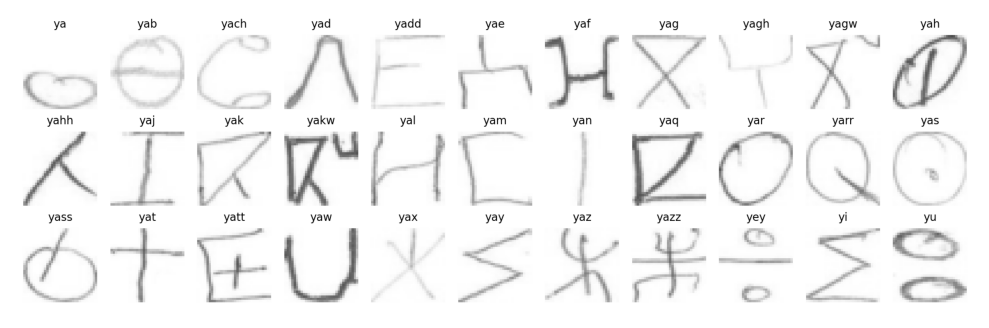

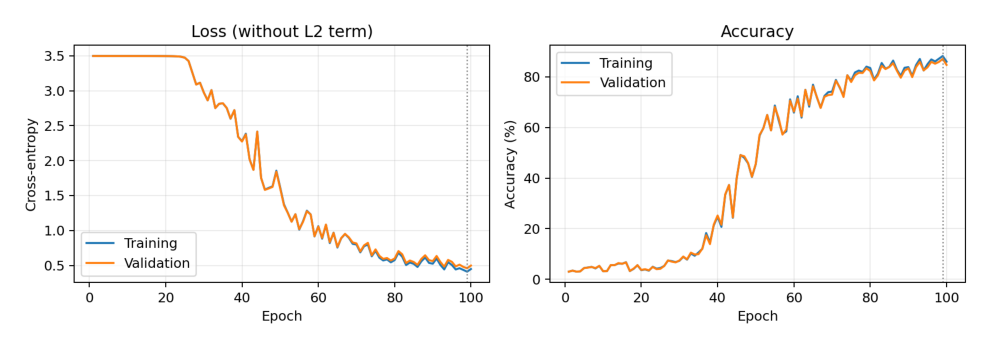

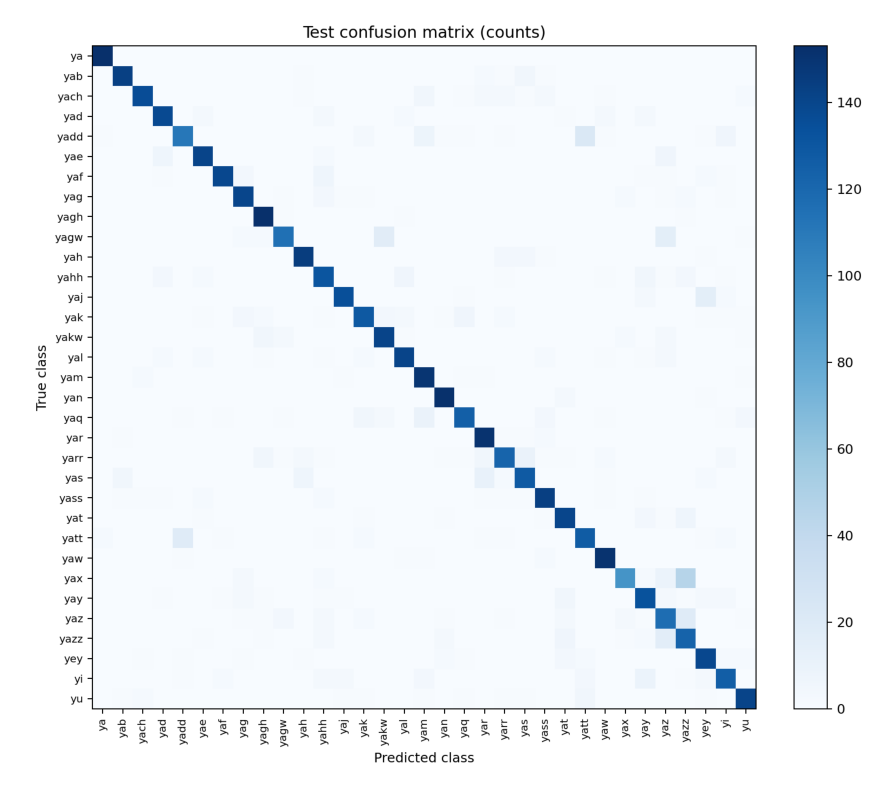

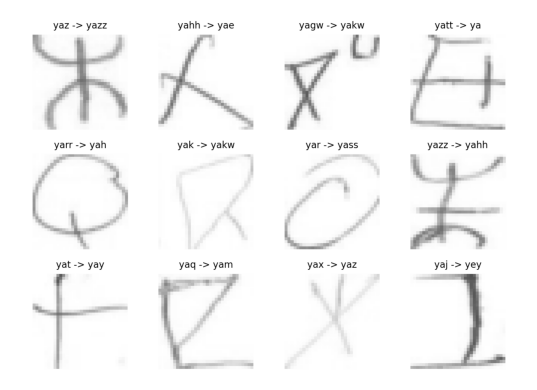

In [5]:
display_folder = Path("results/baseline")
for filename in ["examples.png", "curves.png", "confusion.png", "errors.png"]:
    image = plt.imread(display_folder/filename)
    plt.figure(figsize=(11,8) if filename=="confusion.png" else (10,4))
    plt.imshow(image);plt.axis("off");plt.tight_layout();plt.show()
